In [1]:
import random
import time

In [2]:
from chess_functions_2 import geldige_zetten_pion, geldige_zetten_pion_aanv, geldige_zetten_paard, geldige_zetten_loper
from chess_functions_2 import geldige_zetten_toren, geldige_zetten_koning, geldige_zetten_koningin

In [3]:
from chess_functions_2 import nieuw_bord, toon_bord, doe_zet_met_controle, doe_zet_zonder_controle, check, checkmate
from chess_functions_2 import alle_geldige_zetten, alle_geldige_zetten_score, spel, N_games, random_player, score_player, thinking_one_ahead_player

To do:

- en passant
- rokade
- promotie **CHECK**
- pion die overkant bereikt wordt koningin
- bestanden overzetten van andere computer **CHECK**
- functie geldige_pionnen_aanv (schaak- en schaakmatfunctie aanpassen!) **CHECK**
- functie speel X spelletjes met 2 spelers, elk met hun eigen strategie, die afwisselend met wit en zwart spelen, en kijk wie het vaakst wint **CHECK**
- nieuwe strategie programmeren **CHECK**:
  - alle geldige zetten score geven: bijv. pion score 1, paard score 2, toren en loper score 3, koningin score 4, schaak zetten score 5, schaakmat zetten score 6 (maar kan variabel zijn) **CHECK**
  - zet met hoogste score kiezen **CHECK**
- deze strategie laten spelen tegen random speler **CHECK**
- experimenteren met andere scores
- nieuwe strategie programmeren: 1 zet vooruit denken -> voor elke geldige zet alle tegenzetten oplijsten, voorspellen op basis van score wat andere speler zal doen, dan zet kiezen met hoogste netto-score (rekening houden met: schaakmat -> einde spel) **CHECK**
- manier bedenken om dit sneller te berekenen: alle tegenzetten oplijsten, en voor elke zet berekenen hoe dit de lijst van tegenzetten beïnvloedt, want voor de meeste stukken zullen de tegenzetten niet opnieuw berekend moeten worden
- strategie 1 zet vooruit laten spelen tegen score-strategie enz. **CHECK**

In [10]:
bord = nieuw_bord()
wit = thinking_one_ahead_player('wit')

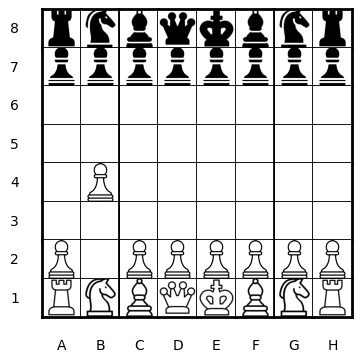

In [11]:
bord, status = wit.make_move(bord)
toon_bord(bord)

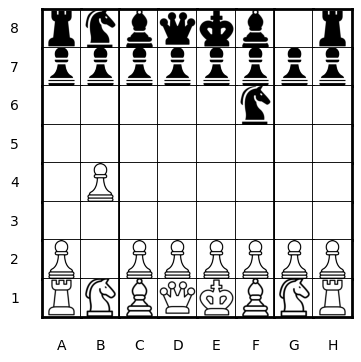

In [12]:
bord = doe_zet_met_controle(bord, 'zwart', [0, 6], [2, 5])
toon_bord(bord)

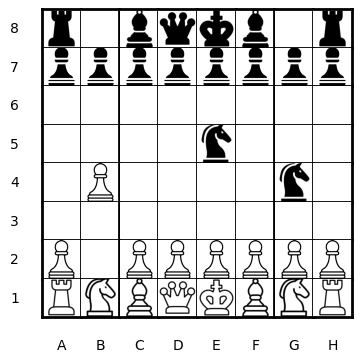

In [13]:
bord = doe_zet_met_controle(bord, 'zwart', [0, 1], [2, 2])
bord = doe_zet_met_controle(bord, 'zwart', [2, 2], [3, 4])
bord = doe_zet_met_controle(bord, 'zwart', [2, 5], [4, 6])
toon_bord(bord)

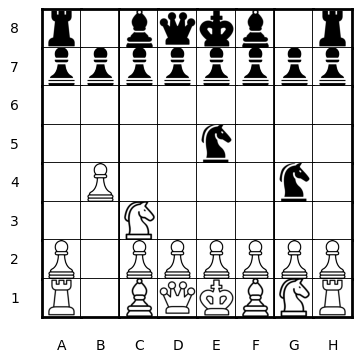

In [14]:
bord, status = wit.make_move(bord)
toon_bord(bord)

In [15]:
bord = doe_zet_met_controle(bord, 'zwart', [4, 6], [3, 4])

Ongeldige zet!


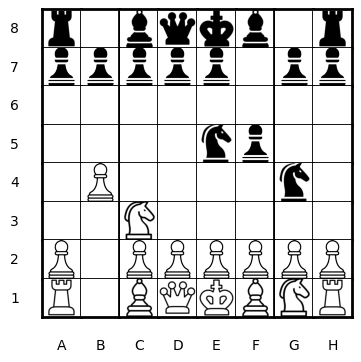

In [16]:
bord = doe_zet_met_controle(bord, 'zwart', [1, 5], [3, 5])
toon_bord(bord)

In [49]:
ch = check(bord, 'wit')
ch

[]

In [50]:
zetten_score = alle_geldige_zetten_score(bord, 'wit')

#if zetten_score:

#m = max([item[2] for item in zetten_score])

#for item in zetten_score:
    #if item[2] == m:
        #beste_zetten.append([item[0], item[1]])

#if m == 6:
    #zet = random.choice(beste_zetten)
    #bord = doe_zet_zonder_controle(bord, 'wit', zet[0], zet[1])
    #return bord, self.status

change_color_map = {"zwart": "wit", "wit": "zwart"}
zetten_nettoscore = []

for zet in zetten_score:
    bord_v = doe_zet_zonder_controle(bord, 'wit', zet[0], zet[1])
    tegenzetten_score = alle_geldige_zetten_score(bord_v, change_color_map['wit'])
    print(max([item[2] for item in tegenzetten_score]))
    
    if tegenzetten_score:
        tegenscore = max([item[2] for item in tegenzetten_score])
    else:
        tegenscore = -7

    zetten_nettoscore.append([zet[0], zet[1], zet[2] - tegenscore])

2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2


In [51]:
#m

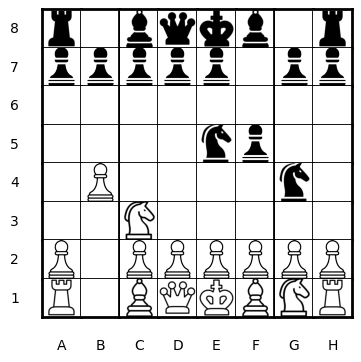

In [52]:
toon_bord(bord)

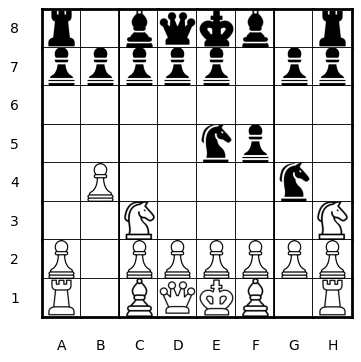

In [53]:
toon_bord(bord_v)

In [54]:
tegenzetten_score

[[[0, 0], [0, 1], 0],
 [[0, 4], [1, 5], 0],
 [[0, 7], [0, 6], 0],
 [[1, 0], [2, 0], 0],
 [[1, 0], [3, 0], 0],
 [[1, 1], [2, 1], 0],
 [[1, 1], [3, 1], 0],
 [[1, 2], [2, 2], 0],
 [[1, 2], [3, 2], 0],
 [[1, 3], [2, 3], 0],
 [[1, 3], [3, 3], 0],
 [[1, 4], [2, 4], 0],
 [[1, 6], [2, 6], 0],
 [[1, 6], [3, 6], 0],
 [[1, 7], [2, 7], 0],
 [[1, 7], [3, 7], 0],
 [[3, 4], [1, 5], 0],
 [[3, 4], [5, 3], 2],
 [[3, 4], [5, 5], 2],
 [[3, 4], [2, 6], 0],
 [[3, 4], [2, 2], 0],
 [[3, 4], [4, 2], 0],
 [[3, 5], [4, 5], 0],
 [[4, 6], [2, 5], 0],
 [[4, 6], [2, 7], 0],
 [[4, 6], [6, 5], 1],
 [[4, 6], [6, 7], 1],
 [[4, 6], [5, 4], 0]]

In [55]:
tegenscore

2

In [56]:
max([item[2] for item in tegenzetten_score])

2

In [40]:
zetten_score

[[[4, 1], [3, 1], 0],
 [[5, 2], [3, 1], 0],
 [[5, 2], [3, 3], 0],
 [[5, 2], [7, 1], 0],
 [[5, 2], [4, 4], 0],
 [[5, 2], [4, 0], 0],
 [[6, 0], [5, 0], 0],
 [[6, 0], [4, 0], 0],
 [[6, 3], [5, 3], 0],
 [[6, 3], [4, 3], 0],
 [[6, 4], [5, 4], 0],
 [[6, 4], [4, 4], 0],
 [[6, 5], [5, 5], 0],
 [[6, 5], [4, 5], 0],
 [[6, 6], [5, 6], 0],
 [[6, 7], [5, 7], 0],
 [[6, 7], [4, 7], 0],
 [[7, 0], [7, 1], 0],
 [[7, 2], [6, 1], 0],
 [[7, 2], [5, 0], 0],
 [[7, 6], [5, 5], 0],
 [[7, 6], [5, 7], 0]]

In [41]:
zetten_nettoscore

[[[4, 1], [3, 1], -2],
 [[5, 2], [3, 1], -2],
 [[5, 2], [3, 3], -2],
 [[5, 2], [7, 1], -2],
 [[5, 2], [4, 4], -2],
 [[5, 2], [4, 0], -2],
 [[6, 0], [5, 0], -2],
 [[6, 0], [4, 0], -2],
 [[6, 3], [5, 3], -2],
 [[6, 3], [4, 3], -2],
 [[6, 4], [5, 4], -2],
 [[6, 4], [4, 4], -2],
 [[6, 5], [5, 5], -2],
 [[6, 5], [4, 5], -2],
 [[6, 6], [5, 6], -2],
 [[6, 7], [5, 7], -2],
 [[6, 7], [4, 7], -2],
 [[7, 0], [7, 1], -2],
 [[7, 2], [6, 1], -2],
 [[7, 2], [5, 0], -2],
 [[7, 6], [5, 5], -2],
 [[7, 6], [5, 7], -2]]

In [36]:
beste_zetten

[[[4, 1], [3, 1]],
 [[5, 2], [3, 1]],
 [[5, 2], [3, 3]],
 [[5, 2], [7, 1]],
 [[5, 2], [4, 4]],
 [[5, 2], [4, 0]],
 [[6, 0], [5, 0]],
 [[6, 0], [4, 0]],
 [[6, 3], [5, 3]],
 [[6, 3], [4, 3]],
 [[6, 4], [5, 4]],
 [[6, 4], [4, 4]],
 [[6, 5], [5, 5]],
 [[6, 5], [4, 5]],
 [[6, 6], [5, 6]],
 [[6, 7], [5, 7]],
 [[6, 7], [4, 7]],
 [[7, 0], [7, 1]],
 [[7, 2], [6, 1]],
 [[7, 2], [5, 0]],
 [[7, 6], [5, 5]],
 [[7, 6], [5, 7]],
 [[4, 1], [3, 1]],
 [[5, 2], [3, 1]],
 [[5, 2], [3, 3]],
 [[5, 2], [7, 1]],
 [[5, 2], [4, 4]],
 [[5, 2], [4, 0]],
 [[6, 0], [5, 0]],
 [[6, 0], [4, 0]],
 [[6, 3], [5, 3]],
 [[6, 3], [4, 3]],
 [[6, 4], [5, 4]],
 [[6, 4], [4, 4]],
 [[6, 5], [5, 5]],
 [[6, 5], [4, 5]],
 [[6, 6], [5, 6]],
 [[6, 7], [5, 7]],
 [[6, 7], [4, 7]],
 [[7, 0], [7, 1]],
 [[7, 2], [6, 1]],
 [[7, 2], [5, 0]],
 [[7, 6], [5, 5]],
 [[7, 6], [5, 7]]]

In [57]:
alle_geldige_zetten_score(bord, 'zwart')

[[[0, 0], [0, 1], 0],
 [[0, 4], [1, 5], 0],
 [[0, 7], [0, 6], 0],
 [[1, 0], [2, 0], 0],
 [[1, 0], [3, 0], 0],
 [[1, 1], [2, 1], 0],
 [[1, 1], [3, 1], 0],
 [[1, 2], [2, 2], 0],
 [[1, 2], [3, 2], 0],
 [[1, 3], [2, 3], 0],
 [[1, 3], [3, 3], 0],
 [[1, 4], [2, 4], 0],
 [[1, 6], [2, 6], 0],
 [[1, 6], [3, 6], 0],
 [[1, 7], [2, 7], 0],
 [[1, 7], [3, 7], 0],
 [[3, 4], [1, 5], 0],
 [[3, 4], [5, 3], 2],
 [[3, 4], [5, 5], 2],
 [[3, 4], [2, 6], 0],
 [[3, 4], [2, 2], 0],
 [[3, 4], [4, 2], 0],
 [[3, 5], [4, 5], 0],
 [[4, 6], [2, 5], 0],
 [[4, 6], [2, 7], 0],
 [[4, 6], [6, 5], 1],
 [[4, 6], [6, 7], 1],
 [[4, 6], [5, 4], 0]]

In [60]:
score_map = {0: 0, "pion": 1, "paard": 2, "toren": 3, "loper": 3, "koningin": 4}
change_color_map = {"zwart": "wit", "wit": "zwart"}

geldige_zetten = alle_geldige_zetten(bord, 'zwart')
geldige_zetten_score = []

#for zet in geldige_zetten:
zet = [[3, 4], [5, 3]]
bord_v = doe_zet_zonder_controle(bord, 'zwart', zet[0], zet[1])

check_v_other = check(bord_v, change_color_map['zwart'])

if check_v_other:
    ch_mt, oplossingen = checkmate(bord_v, change_color_map['zwart'])

    if ch_mt:
        geldige_zetten_score.append([zet[0], zet[1], 6])  # schaakmat
    else:
        geldige_zetten_score.append([zet[0], zet[1], 2])  # schaak

else:
    score = score_map[bord[zet[1][0]][zet[1][1]][1]]
    geldige_zetten_score.append([zet[0], zet[1], score])

In [62]:
geldige_zetten_score

[[[3, 4], [5, 3], 2]]

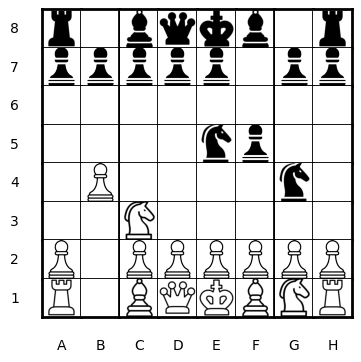

In [66]:
toon_bord(bord)

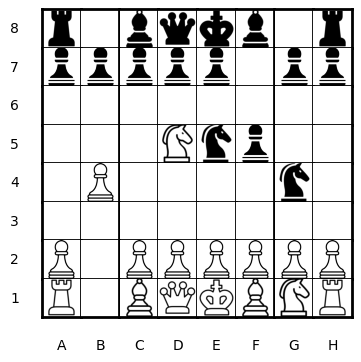

In [67]:
bord, status = wit.make_move(bord)
toon_bord(bord)

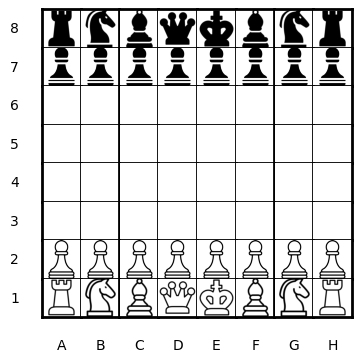

In [95]:
bord = nieuw_bord()
wit = thinking_one_ahead_player('wit')

toon_bord(bord)

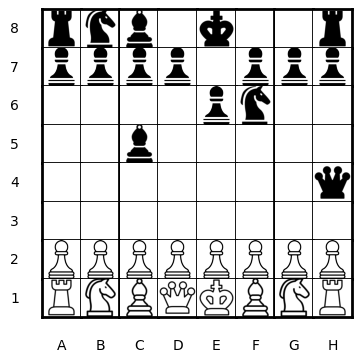

In [96]:
bord = doe_zet_met_controle(bord, 'zwart', [1, 4], [2, 4])
bord = doe_zet_met_controle(bord, 'zwart', [0, 3], [4, 7])
bord = doe_zet_met_controle(bord, 'zwart', [0, 5], [3, 2])
bord = doe_zet_met_controle(bord, 'zwart', [0, 6], [2, 5])

toon_bord(bord)

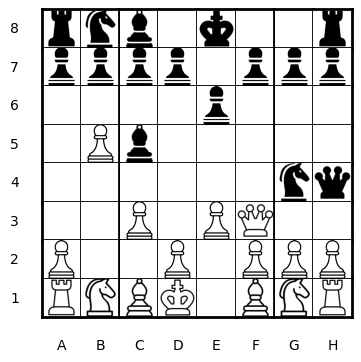

In [97]:
bord = doe_zet_met_controle(bord, 'zwart', [2, 5], [4, 6])

bord = doe_zet_met_controle(bord, 'wit', [6, 1], [4, 1])
bord = doe_zet_met_controle(bord, 'wit', [4, 1], [3, 1])
bord = doe_zet_met_controle(bord, 'wit', [6, 2], [5, 2])
bord = doe_zet_met_controle(bord, 'wit', [6, 4], [5, 4])
bord = doe_zet_met_controle(bord, 'wit', [7, 3], [5, 5])
bord = doe_zet_met_controle(bord, 'wit', [7, 4], [7, 3])

toon_bord(bord)

In [98]:
zetten_score = alle_geldige_zetten_score(bord, 'wit')

#if zetten_score:

#m = max([item[2] for item in zetten_score])

#for item in zetten_score:
    #if item[2] == m:
        #beste_zetten.append([item[0], item[1]])

#if m == 6:
    #zet = random.choice(beste_zetten)
    #bord = doe_zet_zonder_controle(bord, 'wit', zet[0], zet[1])
    #return bord, self.status

change_color_map = {"zwart": "wit", "wit": "zwart"}
zetten_nettoscore = []

for zet in zetten_score:
    bord_v = doe_zet_zonder_controle(bord, 'wit', zet[0], zet[1])
    tegenzetten_score = alle_geldige_zetten_score(bord_v, change_color_map['wit'])
    #print(max([item[2] for item in tegenzetten_score]))
    
    if tegenzetten_score:
        tegenscore = max([item[2] for item in tegenzetten_score])
    else:
        tegenscore = -7

    zetten_nettoscore.append([zet[0], zet[1], zet[2] - tegenscore])

In [99]:
zetten_score

[[[3, 1], [2, 1], 0],
 [[5, 2], [4, 2], 0],
 [[5, 4], [4, 4], 0],
 [[5, 5], [6, 4], 0],
 [[5, 5], [4, 4], 0],
 [[5, 5], [3, 3], 0],
 [[5, 5], [2, 2], 0],
 [[5, 5], [1, 1], 1],
 [[5, 5], [4, 6], 2],
 [[5, 5], [4, 5], 0],
 [[5, 5], [3, 5], 0],
 [[5, 5], [2, 5], 0],
 [[5, 5], [1, 5], 2],
 [[5, 5], [5, 6], 0],
 [[5, 5], [5, 7], 0],
 [[6, 0], [5, 0], 0],
 [[6, 0], [4, 0], 0],
 [[6, 3], [5, 3], 0],
 [[6, 3], [4, 3], 0],
 [[6, 6], [5, 6], 0],
 [[6, 7], [5, 7], 0],
 [[7, 1], [5, 0], 0],
 [[7, 2], [6, 1], 0],
 [[7, 2], [5, 0], 0],
 [[7, 3], [6, 2], 0],
 [[7, 3], [6, 4], 0],
 [[7, 3], [7, 4], 0],
 [[7, 5], [6, 4], 0],
 [[7, 5], [5, 3], 0],
 [[7, 5], [4, 2], 0],
 [[7, 6], [5, 7], 0],
 [[7, 6], [6, 4], 0]]

In [100]:
zetten_nettoscore

[[[3, 1], [2, 1], -2],
 [[5, 2], [4, 2], -2],
 [[5, 4], [4, 4], -2],
 [[5, 5], [6, 4], -2],
 [[5, 5], [4, 4], -2],
 [[5, 5], [3, 3], -4],
 [[5, 5], [2, 2], -4],
 [[5, 5], [1, 1], -3],
 [[5, 5], [4, 6], 0],
 [[5, 5], [4, 5], -2],
 [[5, 5], [3, 5], -4],
 [[5, 5], [2, 5], -4],
 [[5, 5], [1, 5], -2],
 [[5, 5], [5, 6], -4],
 [[5, 5], [5, 7], -4],
 [[6, 0], [5, 0], -2],
 [[6, 0], [4, 0], -2],
 [[6, 3], [5, 3], -2],
 [[6, 3], [4, 3], -2],
 [[6, 6], [5, 6], -2],
 [[6, 7], [5, 7], -2],
 [[7, 1], [5, 0], -2],
 [[7, 2], [6, 1], -2],
 [[7, 2], [5, 0], -3],
 [[7, 3], [6, 2], -2],
 [[7, 3], [6, 4], -2],
 [[7, 3], [7, 4], -2],
 [[7, 5], [6, 4], -2],
 [[7, 5], [5, 3], -2],
 [[7, 5], [4, 2], -2],
 [[7, 6], [5, 7], -2],
 [[7, 6], [6, 4], -2]]

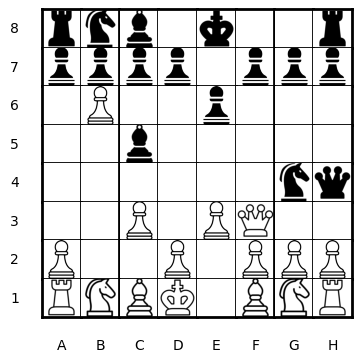

In [101]:
zet = [[3, 1], [2, 1], 0]
bord_v = doe_zet_zonder_controle(bord, 'wit', zet[0], zet[1])
toon_bord(bord_v)

In [102]:
tegenzetten_score = alle_geldige_zetten_score(bord_v, 'zwart')
tegenzetten_score

[[[0, 1], [2, 0], 0],
 [[0, 1], [2, 2], 0],
 [[0, 4], [0, 3], 0],
 [[0, 4], [0, 5], 0],
 [[0, 4], [1, 4], 0],
 [[0, 7], [0, 6], 0],
 [[0, 7], [0, 5], 0],
 [[1, 0], [2, 0], 0],
 [[1, 0], [3, 0], 0],
 [[1, 0], [2, 1], 1],
 [[1, 2], [2, 2], 0],
 [[1, 2], [2, 1], 1],
 [[1, 3], [2, 3], 0],
 [[1, 3], [3, 3], 0],
 [[1, 5], [2, 5], 0],
 [[1, 5], [3, 5], 0],
 [[1, 6], [2, 6], 0],
 [[1, 6], [3, 6], 0],
 [[1, 7], [2, 7], 0],
 [[1, 7], [3, 7], 0],
 [[2, 4], [3, 4], 0],
 [[3, 2], [4, 3], 0],
 [[3, 2], [5, 4], 1],
 [[3, 2], [4, 1], 0],
 [[3, 2], [5, 0], 0],
 [[3, 2], [2, 1], 1],
 [[3, 2], [2, 3], 0],
 [[3, 2], [1, 4], 0],
 [[3, 2], [0, 5], 0],
 [[4, 6], [2, 5], 0],
 [[4, 6], [2, 7], 0],
 [[4, 6], [6, 5], 2],
 [[4, 6], [6, 7], 1],
 [[4, 6], [3, 4], 0],
 [[4, 6], [5, 4], 2],
 [[4, 7], [5, 6], 0],
 [[4, 7], [6, 5], 1],
 [[4, 7], [3, 6], 0],
 [[4, 7], [2, 5], 0],
 [[4, 7], [1, 4], 0],
 [[4, 7], [0, 3], 0],
 [[4, 7], [5, 7], 0],
 [[4, 7], [6, 7], 1],
 [[4, 7], [3, 7], 0],
 [[4, 7], [2, 7], 0]]

In [103]:
zet = [[4, 6], [6, 5]]

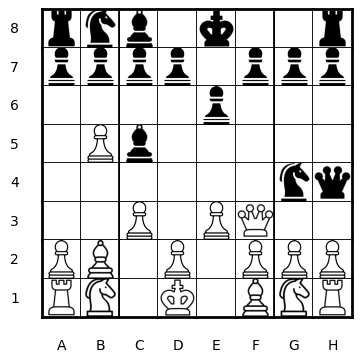

In [104]:
bord = doe_zet_met_controle(bord, 'wit', [7, 2], [6, 1])
toon_bord(bord)

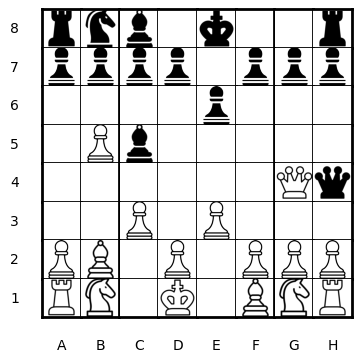

In [105]:
bord, status = wit.make_move(bord)
toon_bord(bord) # Is dus WEL DEGELIJK LOGISCH. Plus 2 en daarna -2 (niet -4) want door de koningin te veroveren kan zwart wit schaak zetten. Netto-resultaat is nul. 
# Anders was netto-resultaat min 1 (want sowieso ergens een pion kwijt)
# Conclusie: score moet cumulatief zijn -> schaak zetten + koningin veroveren zou moeten score = 6 zijn (schaakmat dan op 7 zetten want uiteraard altijd hoogste score)

In [ ]:
# FUNCTIE ALLE_GELDIGE_ZETTEN_SCORES AANGEPAST

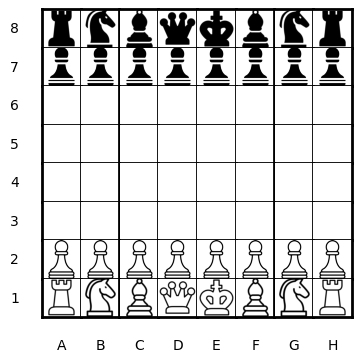

In [4]:
bord = nieuw_bord()
wit = thinking_one_ahead_player('wit')

toon_bord(bord)

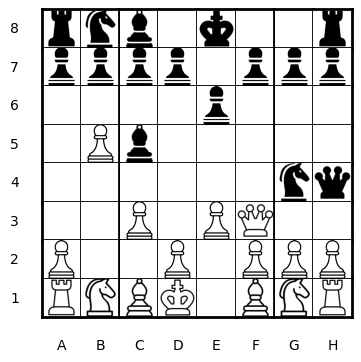

In [5]:
bord = doe_zet_met_controle(bord, 'zwart', [1, 4], [2, 4])
bord = doe_zet_met_controle(bord, 'zwart', [0, 3], [4, 7])
bord = doe_zet_met_controle(bord, 'zwart', [0, 5], [3, 2])
bord = doe_zet_met_controle(bord, 'zwart', [0, 6], [2, 5])
bord = doe_zet_met_controle(bord, 'zwart', [2, 5], [4, 6])

bord = doe_zet_met_controle(bord, 'wit', [6, 1], [4, 1])
bord = doe_zet_met_controle(bord, 'wit', [4, 1], [3, 1])
bord = doe_zet_met_controle(bord, 'wit', [6, 2], [5, 2])
bord = doe_zet_met_controle(bord, 'wit', [6, 4], [5, 4])
bord = doe_zet_met_controle(bord, 'wit', [7, 3], [5, 5])
bord = doe_zet_met_controle(bord, 'wit', [7, 4], [7, 3])

toon_bord(bord)

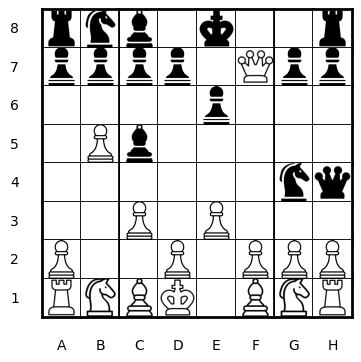

In [6]:
bord, status = wit.make_move(bord)
toon_bord(bord) # Score zet wit = 2 + 1 = 3. Tegenzet normaal gezien koningin veroveren dus -4. Netto = -1. 
# Is het beste resultaat. Paard veroveren -> daarna schaak dus netto -4. Pion veroveren -> daarna schaak dus netto - 3.
# Klopt dus. Ook al zou je dit als speler wss niet doen want je bent koningin meteen kwijt en schaak levert je dus niets op.